# Quantum Computing — Beginner Lab

Welcome! In this notebook you will build and run real quantum circuits with **Qiskit**, and (optionally) run one of them on a **real IBM Quantum computer**.

## How to work through this notebook

1. Make sure your Jupyter kernel is the course environment (`.venv`) — see `README.md`.
2. Run the cells **in order** (top to bottom).
3. Cells marked `# TODO` are yours to complete. Everything else is provided.
4. Every exercise ends with a **self-check** cell. When your solution is right, it prints `✅` — when it's not, it tells you exactly what went wrong.

## What you will build

| # | Exercise |
|---|----------|
| 1 | One qubit in perfect superposition: circuit + measurement results |
| 2 | The four Bell states: circuits + measurement results + the *internal* states |
| 3 | The transformation matrices of all the gates you used |
| 4 | Five 3-qubit target states |
| 5 | *(Bonus)* Run a circuit on a real IBM Quantum computer |

Let's start with the concepts you need.

In [1]:
# Setup — run this first
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Latex
from qiskit import QuantumCircuit
from qclab.runner import simulate, run_on_ibm
from qclab.states import statevector_of, matrix_of, matrix_to_latex
from qclab.viz import draw_circuit, plot_counts, plot_statevector
from qclab.check import assert_statevector, assert_distribution

import qiskit, qiskit_aer, qiskit_ibm_runtime
print("Qiskit:", qiskit.__version__)
print("Aer:", qiskit_aer.__version__)
print("IBM Runtime:", qiskit_ibm_runtime.__version__)
print("All good — let's go!")

Qiskit: 2.5.2
Aer: 0.17.2
IBM Runtime: 0.50.0
All good — let's go!


## 1. What is a qubit?

A classical bit is either `0` or `1`. A **qubit** can be in either state — or in a *superposition* of both:

$$|\psi⟩ = \alpha|0⟩ + \beta|1⟩$$

Here `|0⟩` and `|1⟩` are the **basis states** (written in *Dirac notation*), and `α`, `β` are complex numbers called **amplitudes**. The amplitudes tell you what you will observe when you *measure*:

- you will see `0` with probability $|\alpha|^2$
- you will see `1` with probability $|\beta|^2$

Because these must be valid probabilities, the amplitudes are **normalized**:

$$|\alpha|^2 + |\beta|^2 = 1$$

> **Example:** $|\psi⟩ = \tfrac{1}{\sqrt{2}}|0⟩ + \tfrac{1}{\sqrt{2}}|1⟩$ means: measure it, and you get `0` 50% of the time and `1` 50% of the time.

## 2. Superposition and the statevector

For *multiple* qubits, the state is a superposition of **all** basis states at once. With 2 qubits there are $2^2 = 4$ basis states, so a state looks like:

$$|\psi⟩ = a_{00}|00⟩ + a_{01}|01⟩ + a_{10}|10⟩ + a_{11}|11⟩$$

The full list of amplitudes is called the **statevector**. It is the complete, exact description of the state — more information than you can ever get out of measurements:

- 1 qubit → 2 amplitudes
- 2 qubits → 4 amplitudes
- 3 qubits → 8 amplitudes
- n qubits → $2^n$ amplitudes (this exponential growth is why quantum computers are interesting!)

### ⚠️ The qubit-ordering convention (important!)

When we write `|abc⟩` or see a bit-string like `"101"` in the measurement results, **the leftmost character is the *highest*-numbered qubit** (Qiskit's standard):

$$|abc⟩ \;\Longrightarrow\; \text{qubit 2} = a,\quad \text{qubit 1} = b,\quad \text{qubit 0} = c$$

So `"101"` means: qubit 2 = 1, qubit 1 = 0, qubit 0 = 1. And in a circuit *drawing*, qubit 0 is drawn on the **bottom** line and qubit 2 on the top line.

## 3. Measurement

You can only *see* a quantum state by **measuring** it. Measurement has two important properties:

1. **Random outcome.** Measuring $\alpha|0⟩ + \beta|1⟩$ gives `0` with probability $|\alpha|^2$ and `1` with probability $|\beta|^2$ (this is called the *Born rule*). The exact outcome is unpredictable — only the probabilities are fixed.
2. **Destructive.** After a measurement the superposition is *gone*: the qubit collapses to the basis state you observed. You cannot run the same measurement twice on the same state.

Because of that, we never measure the state *once*. We run the whole circuit many times — each run is called a **shot** — and collect a **histogram of counts**: how many times each bit-string came out. The counts let us *estimate* the probabilities.

> **Key insight for this course:** a histogram only shows *probabilities* (the sizes of the amplitudes). It does **not** show the *phases* of the amplitudes. Two different quantum states can give **identical** measurement results but have different internal states. You will see exactly this in Exercise 2 — that is why we also look at the **statevector**, which only the simulator can give us. (Real quantum computers never return statevectors, only counts!)

## 4. Gates — the operations you can apply

Quantum gates are reversible transformations implemented as **unitary matrices**. You will use three:

| Gate | Qiskit | What it does |
|------|--------|--------------|
| **H** (Hadamard) | `qc.h(q)` | Turns a basis state into a perfect superposition: $H|0⟩ = \tfrac{|0⟩+|1⟩}{\sqrt{2}}$ and $H|1⟩ = \tfrac{|0⟩-|1⟩}{\sqrt{2}}$ |
| **X** (NOT / bit-flip) | `qc.x(q)` | Flips the qubit: $X|0⟩ = |1⟩$, $X|1⟩ = |0⟩$ |
| **CX** (CNOT) | `qc.cx(c, t)` | *Controlled* NOT: flips target `t` **only if** control `c` is `1`. This is what creates **entanglement**. |

The exact matrices of these gates are the subject of Exercise 3 — for now, just trust that `H`, `X` and `CX` do what the table says.

## 5. A first look: building and drawing a circuit in Qiskit

Let's build the simplest possible circuit — a Hadamard on one qubit, then a measurement — and see what Qiskit gives us:

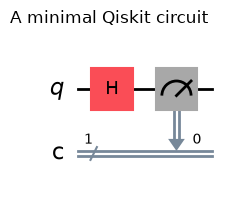

In [2]:
# A minimal circuit: 1 qubit, 1 classical bit, H gate, then measurement
demo = QuantumCircuit(1, 1)
demo.h(0)        # Hadamard on qubit 0
demo.measure(0, 0)  # measure qubit 0 into classical bit 0

draw_circuit(demo, "A minimal Qiskit circuit")

The circuit *drawing* shows the qubit line on top (`q[0]`), the measurement arrow, and the classical bit below (`c[0]`). Gates flow left → right.

Now let's see what happens when we *run* it:

Counts: {'1': 533, '0': 491}


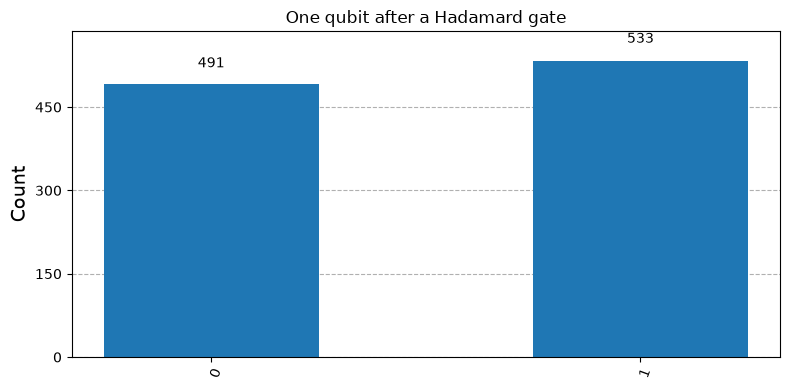

In [3]:
# Run the demo circuit 1024 times on the local simulator
demo_counts = simulate(demo, shots=1024)
print("Counts:", demo_counts)
plot_counts(demo_counts, "One qubit after a Hadamard gate")

Statevector: [0.70710678+0.j 0.70710678+0.j]


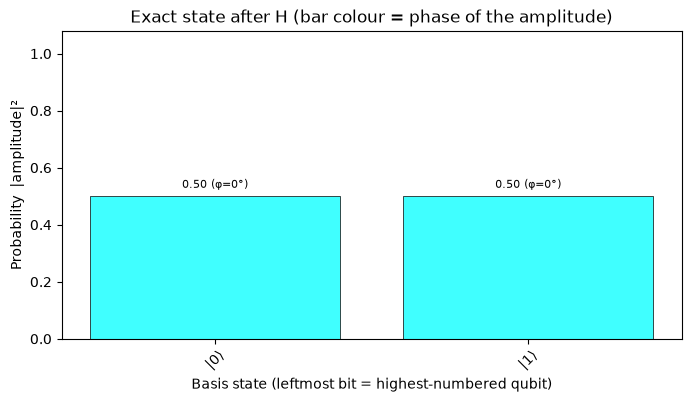

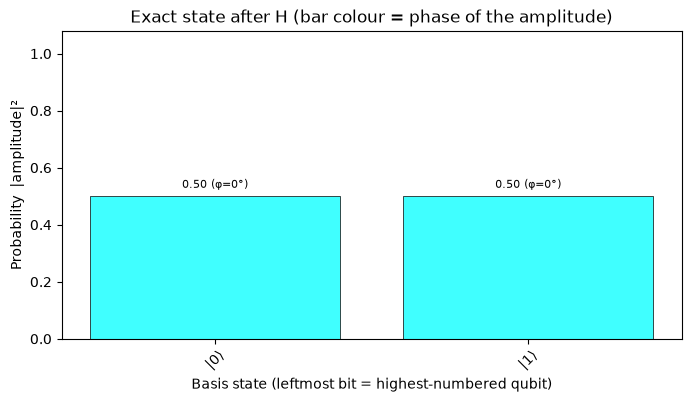

In [4]:
# And the exact statevector of the same circuit (before measurement):
demo_sv = statevector_of(demo)
print("Statevector:", demo_sv.data)
plot_statevector(demo_sv, "Exact state after H (bar colour = phase of the amplitude)")

The histogram shows roughly half `0` and half `1` — that's the superposition in action. The statevector shows the *exact* state: both amplitudes are $1/\sqrt{2} \approx 0.707$ with the same (positive) phase.

You now have everything you need. Time to build things yourself!

---
# Exercise 1 — One qubit in perfect superposition

**Goal:** build a 1-qubit circuit that puts the qubit in a *perfect superposition* of the two basis states — i.e. $|\psi⟩ = \tfrac{1}{\sqrt{2}}|0⟩ + \tfrac{1}{\sqrt{2}}|1⟩$ — and show:

1. the **circuit** (as a drawing),
2. the **measurement results** (a histogram of counts),
3. the exact **statevector**,
4. the **transformation matrix** of the gate you used.

**What you should see:** about 50% `0` and 50% `1` in the histogram (with small random fluctuations — that's normal and even with more shots it will never be exactly 512/512).

In [ ]:
# --- Exercise 1: build the circuit ---
q1 = QuantumCircuit(1, 1)

# TODO: put the qubit into a perfect superposition of |0> and |1>.
# (One gate is enough. Which one? Think about what the demo above used.)


# TODO: measure qubit 0 into classical bit 0
# q1.measure(0, 0)

draw_circuit(q1, "Exercise 1 — one qubit in perfect superposition")

In [ ]:
# --- Exercise 1: measurement results ---
counts = simulate(q1, shots=1024)
plot_counts(counts, "Exercise 1 — measurement results (1024 shots)")

In [ ]:
# --- Exercise 1: the exact statevector ---
sv = statevector_of(q1)
print("Statevector:", sv.data)
plot_statevector(sv, "Exercise 1 — exact state")

In [ ]:
# --- Exercise 1: the transformation matrix of your gate ---
# TODO: replace 'HGate()' with the gate you used in the circuit above.
from qiskit.circuit.library import HGate, XGate, CXGate

my_gate = HGate()  # TODO: this may already be the right answer!
display(Latex(matrix_to_latex(matrix_of(my_gate))))

In [ ]:
# --- Exercise 1: SELF-CHECK (run this when you are done) ---
assert_statevector(q1, {"0": 1/np.sqrt(2), "1": 1/np.sqrt(2)}, message="Exercise 1 state")
assert_distribution(counts, {"0": 0.5, "1": 0.5}, message="Exercise 1 counts")
print("✅ Exercise 1 checks passed!")

---
# Exercise 2 — The four Bell states

A **Bell state** is a special entangled state of two qubits. The recipe for all four is the same, and it only depends on the *starting* state:

> Start from one of the four basis states `00`, `01`, `10`, `11` → send the **first qubit** through a **Hadamard** gate → then a **CNOT** where the first qubit's result determines what happens to the second qubit.

In Qiskit language (remember: the *first* qubit is qubit `0`, drawn on the bottom):

```
qc = QuantumCircuit(2, 2)
# (X gates to set up the starting state, if needed)
qc.h(0)    # Hadamard on the first qubit
qc.cx(0, 1)  # CNOT: control = qubit 0, target = qubit 1
qc.measure(0, 0)
qc.measure(1, 1)
```

**Task:** build all four circuits (one per starting state), show each circuit, run each of them and show the measurement results. *Then also show the internal state* (the statevector) of each of the four results.

**Watch closely:** the measurement results do **not** differ for every Bell state, but the internal state **does**. Can you see which two give identical counts but different statevectors? (Fill in the table below after you run the circuits.)

In [ ]:
# --- Exercise 2: build the four Bell-state circuits ---
bell_circuits = {}  # will hold: starting-state name -> circuit

# TODO: for each starting basis state in ["00", "01", "10", "11"], build a circuit:
#   1. start from that basis state (apply X gates where a bit is 1 —
#      remember: for "ab", 'a' is qubit 1 and 'b' is qubit 0),
#   2. Hadamard on qubit 0,
#   3. CNOT with control qubit 0, target qubit 1,
#   4. measure both qubits,
#   5. store it:  bell_circuits["<start>"] = qc
#
# Example of the structure for "00" (no X gates needed):
# qc = QuantumCircuit(2, 2)
# qc.h(0)
# qc.cx(0, 1)
# qc.measure(0, 0)
# qc.measure(1, 1)
# bell_circuits["00"] = qc

assert set(bell_circuits) == {"00", "01", "10", "11"}, "Build all four circuits first!"

In [ ]:
# --- Exercise 2: draw + run all four, show the measurement results ---
bell_counts = {}  # starting state -> counts
bell_sv = {}      # starting state -> statevector

for start in ["00", "01", "10", "11"]:
    qc = bell_circuits[start]
    draw_circuit(qc, f"Bell state from |{start}⟩")
    bell_counts[start] = simulate(qc, shots=1024)
    bell_sv[start] = statevector_of(qc)
    plot_counts(bell_counts[start], f"Counts from start |{start}⟩")

In [ ]:
# --- Exercise 2: show the INTERNAL state (statevector) of each Bell state ---
# The bar colour encodes the *phase* of each amplitude (red ≈ 0°, blue ≈ 180°).
# Compare the heights AND the colours!
for start in ["00", "01", "10", "11"]:
    print(f"Start |{start}⟩ → statevector:", np.round(bell_sv[start].data, 3))
    plot_statevector(bell_sv[start], f"Internal state from start |{start}⟩ (colour = phase)")

### Fill in what you observed

| Start | Bell-state name | Measurement results | Internal state (amplitudes) | Same counts as…? |
|-------|-----------------|---------------------|-----------------------------|------------------|
| 00 | Φ⁺ (phi plus) | | | |
| 01 | Φ⁻ (phi minus) | | | |
| 10 | Ψ⁺ (psi plus) | | | |
| 11 | Ψ⁻ (psi minus) | | | |

The four Bell states are:

$$|\Phi^+⟩ = \tfrac{|00⟩+|11⟩}{\sqrt{2}} \qquad |\Phi^-⟩ = \tfrac{|00⟩-|11⟩}{\sqrt{2}}$$
$$|\Psi^+⟩ = \tfrac{|01⟩+|10⟩}{\sqrt{2}} \qquad |\Psi^-⟩ = \tfrac{|01⟩-|10⟩}{\sqrt{2}}$$

Which starts gave you which Bell state? And now the key question: **Φ⁺ and Φ⁻ (or Ψ⁺ and Ψ⁻) have identical measurement results but different internal states** — what do you think the difference is, and why can measurement never detect it?

In [ ]:
# --- Exercise 2: SELF-CHECK ---
# Every Bell state must give exactly 50/50 between two outcomes.
assert_distribution(bell_counts["00"], {"00": 0.5, "11": 0.5}, message="Bell from 00")
assert_distribution(bell_counts["01"], {"00": 0.5, "11": 0.5}, message="Bell from 01")
assert_distribution(bell_counts["10"], {"01": 0.5, "10": 0.5}, message="Bell from 10")
assert_distribution(bell_counts["11"], {"01": 0.5, "10": 0.5}, message="Bell from 11")

# And the internal states of the two 'phi' Bell states must NOT be identical
# (this is the whole point of the exercise):
phi_from_00 = bell_sv["00"].data
phi_from_01 = bell_sv["01"].data
print("Statevector from 00:", np.round(phi_from_00, 3))
print("Statevector from 01:", np.round(phi_from_01, 3))
print("Same internal state?", np.allclose(phi_from_00, phi_from_01))
print("✅ Exercise 2 checks passed!")

---
# Exercise 3 — Transformation matrices

So far we have used the gates `H`, `X` and `CX` on faith. Every gate is actually a **matrix** that transforms the statevector:

$$|\psi_{new}⟩ = U \cdot |\psi_{old}⟩$$

**Task:**
1. Show the transformation matrix of each of the three gates you used: **H**, **X**, **CX**.
2. Show the matrix of the *whole* Bell circuit from Exercise 2 (the product of all its gates — Qiskit computes this for you).
3. Verify by hand: apply the H matrix to $|0⟩$ and confirm you get the same state as in Exercise 1.

In [ ]:
# --- Exercise 3: the matrices of the individual gates ---
# TODO: show the matrix of each gate (use matrix_of() and matrix_to_latex())
for gate, name in [(HGate(), "H"), (XGate(), "X"), (CXGate(), "CX")]:
    print(f"Gate {name}:")
    display(Latex(matrix_to_latex(matrix_of(gate))))

In [ ]:
# --- Exercise 3: the matrix of the WHOLE Bell circuit ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

U_bell = matrix_of(bell)
print("Matrix of the full Bell circuit (4×4):")
display(Latex(matrix_to_latex(U_bell)))

In [ ]:
# --- Exercise 3: verify H|0> by hand ---
from qiskit.quantum_info import Statevector

h = matrix_of(HGate())
result = h @ Statevector.from_label("0")   # matrix @ statevector
print("H |0> =", result.data, "  (should be [0.707..., 0.707...])")

bonus = U_bell @ Statevector.from_label("10")  # TODO: try other starting states,
print("Bell-circuit |10> =", bonus.data, " (compare with the statevector you found in Exercise 2 for start '10')")

> **To think about:** the Bell matrix is a 4×4 matrix, but it only ever maps basis states onto *superpositions of two* states. Can you read off from the matrix which two? (Each column of the matrix is the image of one basis state.)

---
# Exercise 4 — Five 3-qubit target states

Now the main event: construct a 3-qubit state for each of the following five targets, and show the circuit + measurement results. The self-check verifies the *exact* state (statevector) and the counts.

| # | Target |
|---|--------|
| 1 | 100% `\|101⟩` |
| 2 | 50% `\|000⟩` and 50% `\|111⟩` (this is the famous **GHZ state**!) |
| 3 | 50% `\|010⟩` and 50% `\|110⟩` |
| 4 | 50% `\|110⟩` and 50% `\|011⟩` |
| 5 | 50% `\|101⟩` and 50% `\|010⟩` |

### The recipe (read this before you start!)

Think of the two target states as bit-strings, e.g. target 4 is `110` and `011`. Then:

1. **Qubits that are fixed** (same bit in both target states): use an `X` gate if the bit is `1`. Example: target 3 has qubit 1 = `1` in *both* states → `qc.x(1)`. Qubits that are `0` in both need nothing.
2. **Qubits that differ** between the two targets: put one of them (your *seed*) in superposition with `H`, then copy its value to the other differing qubit(s) with `CX` — just like the Bell state, just with more qubits.
3. **Anti-correlation:** if one target has `0` where the other has `1` (the bits differ *in opposite directions*), apply an `X` to that qubit **before** the CNOT copies the seed. Example: target 4 = `110` vs `011`: the seed qubit 2 goes `0 → 1`, but qubit 0 must go `1 → 0` — so flip qubit 0 first with `X`, *then* let the CNOT copy the seed's change onto it.

Take it one target at a time. Target 1 is a warm-up (no superposition at all!).

In [ ]:
# --- Exercise 4: the five target circuits ---
# Complete each function: add gates to 'qc' so that the circuit produces the
# target state. The measurement part is already written for you.

def target_1():
    """Target 1: 100% |101>  (qubit2=1, qubit1=0, qubit0=1)"""
    qc = QuantumCircuit(3, 3)
    # TODO
    for i in range(3):
        qc.measure(i, i)
    return qc

def target_2():
    """Target 2: 50% |000> and 50% |111>  (the GHZ state)"""
    qc = QuantumCircuit(3, 3)
    # TODO
    for i in range(3):
        qc.measure(i, i)
    return qc

def target_3():
    """Target 3: 50% |010> and 50% |110>"""
    qc = QuantumCircuit(3, 3)
    # TODO
    for i in range(3):
        qc.measure(i, i)
    return qc

def target_4():
    """Target 4: 50% |110> and 50% |011>"""
    qc = QuantumCircuit(3, 3)
    # TODO
    for i in range(3):
        qc.measure(i, i)
    return qc

def target_5():
    """Target 5: 50% |101> and 50% |010>"""
    qc = QuantumCircuit(3, 3)
    # TODO
    for i in range(3):
        qc.measure(i, i)
    return qc

In [ ]:
# --- Exercise 4: run all targets and check them ---
s = 1/np.sqrt(2)
targets = [target_1, target_2, target_3, target_4, target_5]
expected_counts = [
    {"101": 1.0},
    {"000": 0.5, "111": 0.5},
    {"010": 0.5, "110": 0.5},
    {"110": 0.5, "011": 0.5},
    {"101": 0.5, "010": 0.5},
]
expected_states = [
    {"101": 1.0},
    {"000": s, "111": s},
    {"010": s, "110": s},
    {"110": s, "011": s},
    {"101": s, "010": s},
]

for i, (build, exp_counts, exp_state) in enumerate(zip(targets, expected_counts, expected_states), start=1):
    qc = build()
    print(f"### Target {i}")
    draw_circuit(qc, f"Target {i}")
    counts = simulate(qc, shots=1024)
    plot_counts(counts, f"Target {i} — measurement results")
    assert_statevector(qc, exp_state, message=f"Target {i} state")
    assert_distribution(counts, exp_counts, message=f"Target {i} counts")
    print(f"✅ Target {i} OK")

---
# Bonus — Run a circuit on a real IBM Quantum computer 🖥️

Everything you ran so far used the **Aer simulator**: perfect physics, but imaginary. You can now run one of your circuits on **real superconducting hardware** in IBM's data centres — for free.

**Before you run this:**

- You need an IBM Cloud account (free) and an **API token**. See `README.md` for the exact steps; put the token in a file called `.env` (template: `.env.example`).
- Real hardware is shared and the free tier has a **small monthly execution budget** (minutes, not hours). So: keep shots modest (1024 is fine) and run only the circuits you really want.
- Expect counts that are **close to** — not identical to — the simulator. Real gates are slightly imperfect (noise). If `00`/`11` come out 48%/52% instead of 50%/50%, that is the quantum computer being real.
- Jobs can sit in a **queue** for a while; the code below waits for the result automatically.

If you don't have a token yet, **skip this section** — everything else in the course works without it, and the cell below fails gracefully.

In [ ]:
# --- Bonus: run the Bell state (from start |00>) on real hardware ---
try:
    real_counts = run_on_ibm(bell_circuits["00"], shots=1024)
    print("\nReal hardware counts:", real_counts)
    plot_counts(real_counts, "Bell state on REAL IBM Quantum hardware")
except Exception as e:
    print("Skipped the real-hardware run (no problem!):")
    print(e)

## Wrap-up — what you now know

- A qubit state is a **statevector**: a list of complex amplitudes with $|\alpha_i|^2$ summing to 1.
    - A **measurement** collapses the state and only ever reveals *probabilities* (counts), never the phases.
- **Gates are unitary matrices**; circuits are their products. You can inspect them all with `matrix_of()`.
- **Entanglement** (Bell states, GHZ states) is created with CNOT gates and is the resource that makes quantum computing powerful.
- **Simulator vs real hardware:** the simulator gives exact states *and* counts; real hardware gives counts only — and with noise.

Congratulations — you have written, run and (optionally) executed-on-real-hardware quantum programs! 🎉